# Step 1: EDA #

## Context: ##

Throughout exploration of various supervised learning algorithms, a common theme is the concept of extracting some signal from a noisy dataset. 

This often applies to datasets where our class of interest (fraud, basketball upset, etc) is in the “minority” class of an imbalanced dataset. 

This problem often occurs in the detection of financial fraud. While we can assume that most transactions are credible, classifying every new sample as non-fraudulent (0) will miss every single fraudulent case. 

Within this project, we will take a look at a synthetic dataset of bank transactions to see which strategies we can take in order to successfully capture as many fraudulent transactions as possible, while also minimizing false positives. 

## Goals: ## 
* Perform univariate, bivariate, and multivariate exploratory analysis. 
* Create relevant graphs that will help formulate a hypothesis.
* Explore the relationships between our predictors and our target variable; the relationship amongst predictors. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("../data/caishen_bank_transactions.csv")

In [2]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
df.shape

(6362620, 11)

In [4]:
df.dtypes

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

In [5]:
df.info

<bound method DataFrame.info of          step      type      amount     nameOrig  oldbalanceOrg  \
0           1   PAYMENT     9839.64  C1231006815      170136.00   
1           1   PAYMENT     1864.28  C1666544295       21249.00   
2           1  TRANSFER      181.00  C1305486145         181.00   
3           1  CASH_OUT      181.00   C840083671         181.00   
4           1   PAYMENT    11668.14  C2048537720       41554.00   
...       ...       ...         ...          ...            ...   
6362615   743  CASH_OUT   339682.13   C786484425      339682.13   
6362616   743  TRANSFER  6311409.28  C1529008245     6311409.28   
6362617   743  CASH_OUT  6311409.28  C1162922333     6311409.28   
6362618   743  TRANSFER   850002.52  C1685995037      850002.52   
6362619   743  CASH_OUT   850002.52  C1280323807      850002.52   

         newbalanceOrig     nameDest  oldbalanceDest  newbalanceDest  isFraud  \
0             160296.36  M1979787155            0.00            0.00        0   
1

In [6]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [7]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

There are no empty values in any of the features

In [8]:
df.value_counts

<bound method DataFrame.value_counts of          step      type      amount     nameOrig  oldbalanceOrg  \
0           1   PAYMENT     9839.64  C1231006815      170136.00   
1           1   PAYMENT     1864.28  C1666544295       21249.00   
2           1  TRANSFER      181.00  C1305486145         181.00   
3           1  CASH_OUT      181.00   C840083671         181.00   
4           1   PAYMENT    11668.14  C2048537720       41554.00   
...       ...       ...         ...          ...            ...   
6362615   743  CASH_OUT   339682.13   C786484425      339682.13   
6362616   743  TRANSFER  6311409.28  C1529008245     6311409.28   
6362617   743  CASH_OUT  6311409.28  C1162922333     6311409.28   
6362618   743  TRANSFER   850002.52  C1685995037      850002.52   
6362619   743  CASH_OUT   850002.52  C1280323807      850002.52   

         newbalanceOrig     nameDest  oldbalanceDest  newbalanceDest  isFraud  \
0             160296.36  M1979787155            0.00            0.00      

In [9]:
df["oldbalanceDest"].value_counts()
df["newbalanceDest"].value_counts()

newbalanceDest
0.00           2439433
10000000.00         53
971418.91           32
19169204.93         29
1254956.07          25
                ...   
188439.36            1
1347758.15           1
3878719.83           1
1605826.83           1
7360101.63           1
Name: count, Length: 3555499, dtype: int64

There are 11 features:
1. `step`: A unit of time that represents hours in the dataset. Think of this as the timestamp of the transaction (e.g. hour 1, hour 2, … hour 534, …) 
2. `type`: The type of transaction 
3. `amount`: The amount of money transferred 
4. `nameOrig`: The origin account name
5. `oldbalanceOrg`: The origin accounts balance before the transaction 
6. `newBalanceOrig`: The origin accounts balance after the transaction 
7. `nameDest`: The destination account name 
8. `oldbalanceDest`: The destination accounts balance before the transaction 
9. `newbalanceDest`: The destination accounts balance after the transaction 
10. `isFraud`: Was this simulated transaction actually fraudulent? In this case, we consider “fraud” to be a malicious transaction that aimed to transfer funds out of a victim’s bank account before the account owner could secure their information. 
11. `isFlaggedFraud`: A “naive” model that simply flags a transaction as fraudulent if it is greater than 200,000 (note that this currency is not USD) 

8 of these are floats or integers while 3 of these (`type`, `nameOrig`, `nameDest`) are objects. Although `nameOrig` and `nameDesti` could contain potentially interesting relationships with the other features, I think I'll drop them since they're difficult to convert into numeric values. `type` is much easier to convert into numbers so I'll go ahead and do that. 

In [10]:
df = pd.get_dummies(df, columns=['type'], drop_first=True)
df.head()

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,False,False,True,False
1,1,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,False,False,True,False
2,1,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,False,False,False,True
3,1,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,True,False,False,False
4,1,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,False,False,True,False


In [11]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


## Univariate Analysis ##


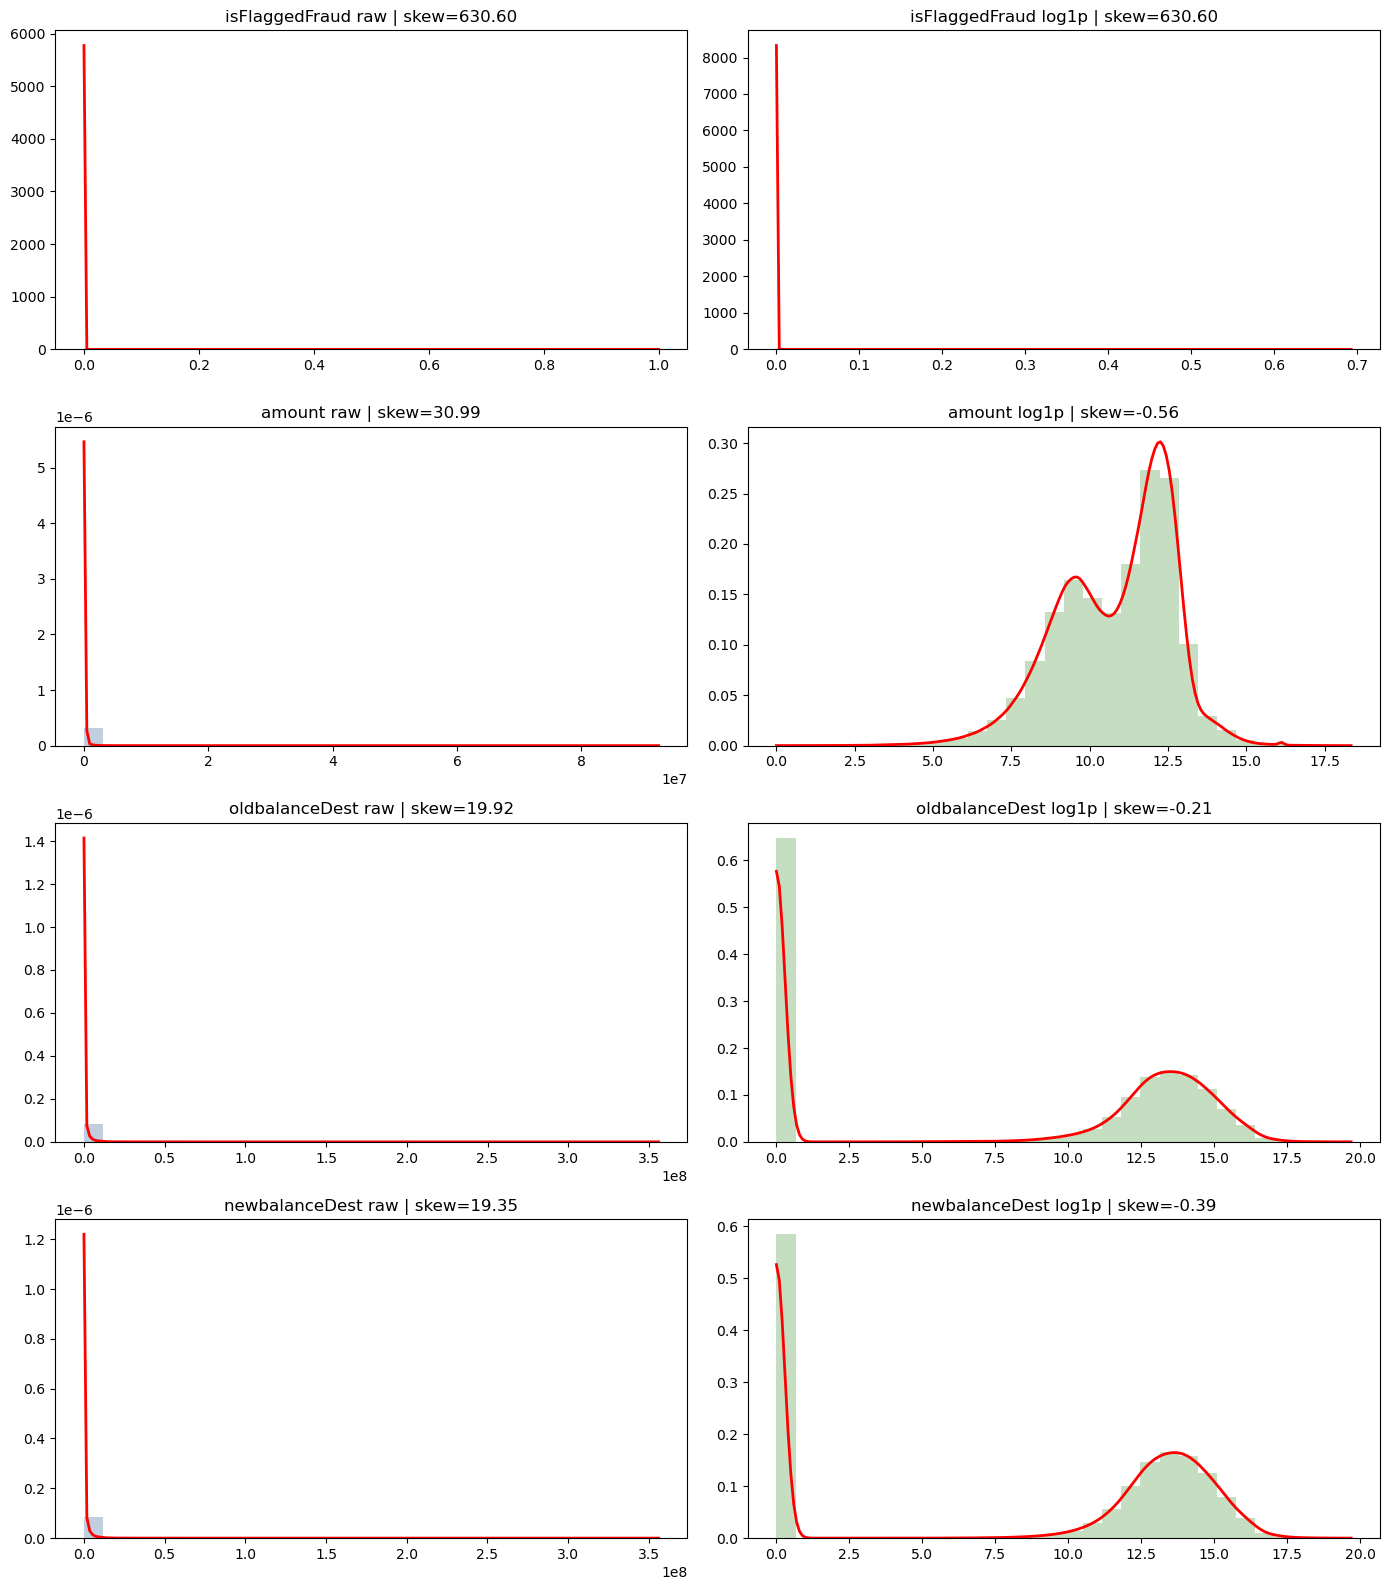

In [29]:
from scipy.stats import gaussian_kde

num_cols = df.select_dtypes(include="number").columns
skews = df[num_cols].skew(numeric_only=True).abs().sort_values(ascending=False)

plot_cols = [c for c in skews.index if c != "isFraud"][:4]

fig, axes = plt.subplots(len(plot_cols), 2, figsize=(14, 4 * len(plot_cols)))
if len(plot_cols) == 1:
    axes = np.array([axes])

for i, col in enumerate(plot_cols):
    raw = df[col].dropna()
    logv = np.log1p(raw[raw >= 0])

    for ax, data, title, color in [
        (axes[i, 0], raw, f"{col} raw", "#4c78a8"),
        (axes[i, 1], logv, f"{col} log1p", "#59a14f"),
    ]:
        ax.hist(data, bins=30, density=True, alpha=0.35, color=color)
        if len(data) > 1 and data.nunique() > 1:
            kde = gaussian_kde(data)
            x = np.linspace(data.min(), data.max(), 200)
            ax.plot(x, kde(x), color="red", linewidth=2)
        ax.set_title(f"{title} | skew={data.skew():.2f}")

plt.tight_layout()
plt.show()

Most numerical features, especially the monetary variables, are highly right-skewed. A log transformation could reduce that skew and lessen the impact of extreme values, but it would not change the strong class imbalance in `isFraud`, since the target labels stay the same. 

Because I plan to use tree-based methods like Random Forest, which are generally less sensitive to skewed feature distributions and feature scaling, I do not expect log transformation to make a major difference. 

For this classification problem, the more important question is not whether the variables look more normal, but whether any transformation helps the model detect the minority class more effectively. My expectation is that the fraud signal is more likely driven by transaction-specific patterns and split points than by the overall shape of the feature distributions.

In [13]:
df['isFraud'].value_counts()


isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [14]:
print(f"{8213/(8213+6354407)*100:.2f}% of values are actually frauds.")
print(f"{6354407/(8213+6354407)*100:.2f}% of values are not actually frauds.")


0.13% of values are actually frauds.
99.87% of values are not actually frauds.


There is a very strong imbalance between fraud and non-fraud transactions, with fraud making up only a tiny fraction of the dataset. This could create a modeling challenge because a classifier can achieve high accuracy by predicting the majority class, while still failing to identify fraudulent transactions. 

Likely metrics like precision, recall, and F1 score will be more meaningful than accuracy for this. The imbalance also means the fraud class is underrepresented, so the model may need feature engineering, resampling, or class-aware evaluation to learn useful fraud patterns.

In [15]:
df['isFlaggedFraud'].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

Objectively, `isFlaggedFraud` has extremely low sensitivity to the fraud class, which makes it ineffective for identifying the rare positive cases that matter most in this imbalanced dataset.

## Bivariate Analysis ##

I wonder whether fraud is concentrated in certain transaction patterns. To test this, I will compare fraud rates across transaction types, amount ranges, and time periods to see which features separate fraudulent from non-fraudulent transactions most clearly. 

In [16]:
type_cols = ['type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']

# Reshape to get one row per transaction type
plot_df = df.melt(
    id_vars='isFraud', 
    value_vars=type_cols, 
    var_name='type', 
    value_name='present'
).query('present == 1')  # Only actual transaction types

# Calculate fraud percentage
fraud_pct = (
    plot_df.groupby('type')['isFraud']
    .agg(['count', 'mean'])
    .round(4)
    .rename(columns={'count': 'total', 'mean': 'fraud_pct'})
    .assign(fraud_pct=lambda x: (x['fraud_pct'] * 100).round(2))
)

print(fraud_pct)

                 total  fraud_pct
type                             
type_CASH_OUT  2237500       0.18
type_DEBIT       41432       0.00
type_PAYMENT   2151495       0.00
type_TRANSFER   532909       0.77


Looks like `type_TRANSFER` and `type_CASH_OUT` are the most likely to be actually fraud

Are big changes in the `amount` also a sign of potential fraud?

In [17]:
df.groupby("isFraud")[["amount"]].describe()

amount                                                           \
             count          mean           std   min         25%        50%   
isFraud                                                                       
0        6354407.0  1.781970e+05  5.962370e+05  0.01   13368.395   74684.72   
1           8213.0  1.467967e+06  2.404253e+06  0.00  127091.330  441423.44   

                                  
                75%          max  
isFraud                           
0         208364.76  92445516.64  
1        1517771.48  10000000.00

Looks like frauds tend to have higher amount than non-frauds.

/var/folders/c2/16tbpph161n8gl8y963rn5800000gn/T/ipykernel_16608/1987414222.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot([df_nf["amount"], df_f["amount"]],


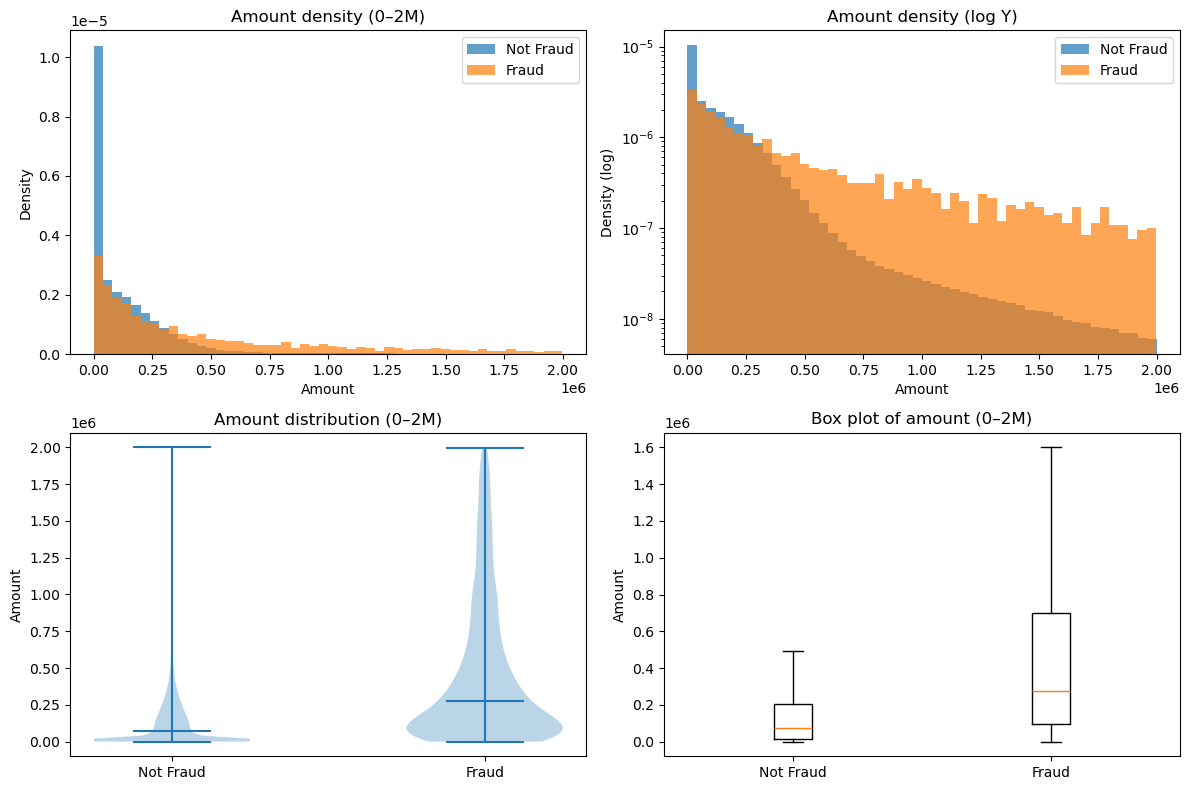

In [18]:
# Focus on the “normal” range (e.g., up to 2M)
upper_limit = 2e6

df_nf = df[(df["isFraud"] == 0) & (df["amount"] <= upper_limit)]
df_f  = df[(df["isFraud"] == 1) & (df["amount"] <= upper_limit)]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Normalized histogram (same y‑scale, shows shape)
axes[0, 0].hist(df_nf["amount"], bins=50, alpha=0.7, label="Not Fraud", density=True)
axes[0, 0].hist(df_f["amount"],  bins=50, alpha=0.7, label="Fraud", density=True)
axes[0, 0].set_title("Amount density (0–2M)")
axes[0, 0].set_xlabel("Amount")
axes[0, 0].set_ylabel("Density")
axes[0, 0].legend()

# 2. Overlap but with log Y to see low‑density regions
axes[0, 1].hist(df_nf["amount"], bins=50, alpha=0.7, label="Not Fraud", density=True)
axes[0, 1].hist(df_f["amount"],  bins=50, alpha=0.7, label="Fraud", density=True)
axes[0, 1].set_title("Amount density (log Y)")
axes[0, 1].set_xlabel("Amount")
axes[0, 1].set_ylabel("Density (log)")
axes[0, 1].set_yscale("log")
axes[0, 1].legend()

# 3. Violin plot: shows *where* each class sits
axes[1, 0].violinplot([df_nf["amount"], df_f["amount"]], positions=[0, 1], showmedians=True)
axes[1, 0].set_xticks([0, 1], labels=["Not Fraud", "Fraud"])
axes[1, 0].set_title("Amount distribution (0–2M)")
axes[1, 0].set_ylabel("Amount")

# 4. Box plot: shows median and spread
axes[1, 1].boxplot([df_nf["amount"], df_f["amount"]],
                   labels=["Not Fraud", "Fraud"], showfliers=False)
axes[1, 1].set_title("Box plot of amount (0–2M)")
axes[1, 1].set_ylabel("Amount")

plt.tight_layout()
plt.show()

Transaction Frequency by Amount Bucket:
amount
Low       2120873
Medium    2120873
High      2120874
Name: count, dtype: int64
               total_count  mean_amount  median_amount  fraud_rate  fraud_pct
amount_bucket                                                                
Low                2120873    8877.3365       7901.040      0.0003       0.03
Medium             2120873   79439.3546      74871.800      0.0009       0.09
High               2120874  451268.8915     277268.905      0.0028       0.28


/var/folders/c2/16tbpph161n8gl8y963rn5800000gn/T/ipykernel_16608/2126271740.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  }).groupby("amount_bucket").agg({


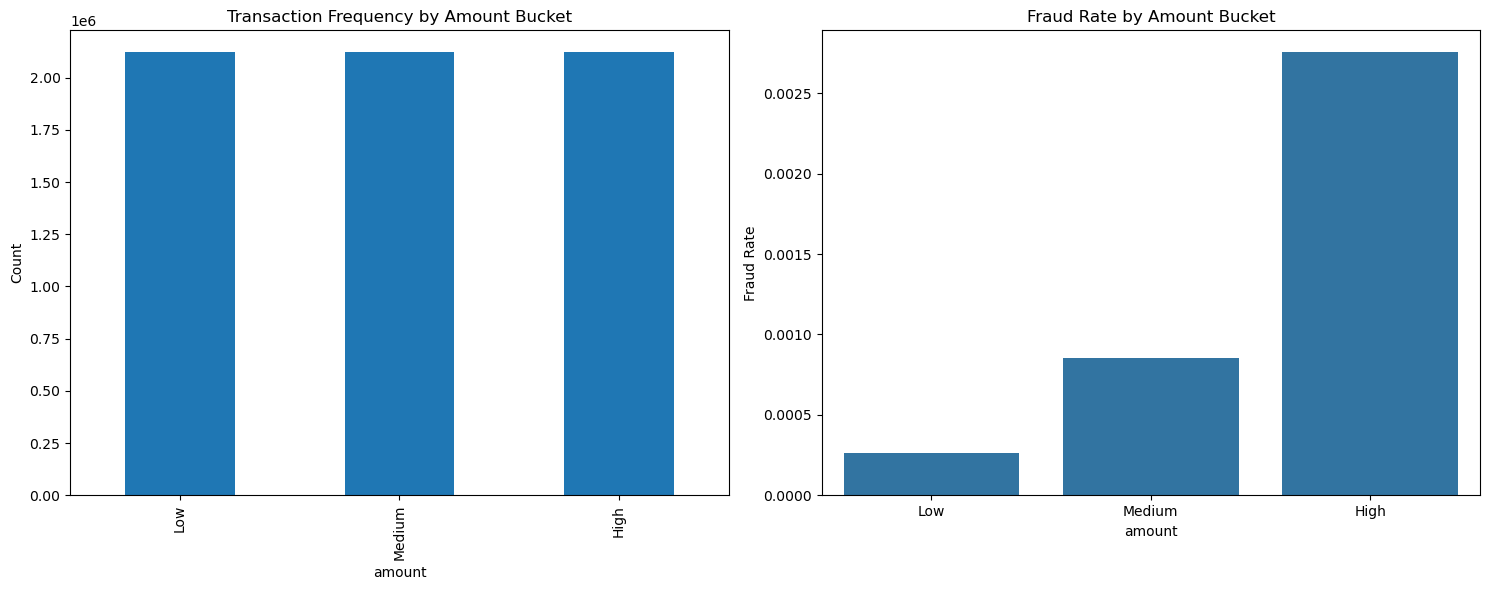

In [19]:
# 1. Create bucket labels without adding a column
amount_bucket = pd.qcut(df["amount"], q=3, labels=["Low", "Medium", "High"])

# 2. Frequency by bucket
bucket_freq = amount_bucket.value_counts().sort_index()
print("Transaction Frequency by Amount Bucket:")
print(bucket_freq)

# 3. Aggregation by bucket
bucket_analysis = pd.DataFrame({
    "amount_bucket": amount_bucket,
    "amount": df["amount"],
    "isFraud": df["isFraud"]
}).groupby("amount_bucket").agg({
    "amount": ["count", "mean", "median"],
    "isFraud": "mean"
}).round(4)

bucket_analysis["fraud_pct"] = (bucket_analysis[("isFraud", "mean")] * 100).round(2)
bucket_analysis.columns = ["total_count", "mean_amount", "median_amount", "fraud_rate", "fraud_pct"]

print(bucket_analysis)

# 4. Plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Frequency
bucket_freq.plot(kind="bar", ax=axes[0])
axes[0].set_title("Transaction Frequency by Amount Bucket")
axes[0].set_ylabel("Count")

# Fraud rate (need to pass bucket labels as a Series, not a column)
sns.barplot(
    x=amount_bucket,
    y=df["isFraud"],
    estimator="mean",
    errorbar=None,
    ax=axes[1]
)
axes[1].set_title("Fraud Rate by Amount Bucket")
axes[1].set_ylabel("Fraud Rate")

plt.tight_layout()
plt.show()

Are certain times more likely to have fraud?

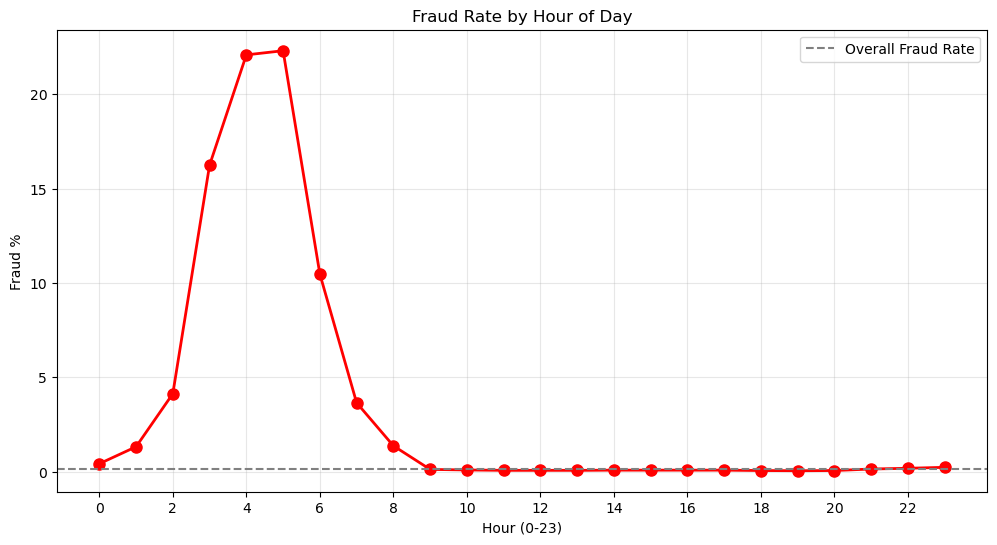

In [21]:
# Convert step to hourly pattern
df['hour'] = df['step'] % 24

hourly_fraud = df.groupby('hour')['isFraud'].agg(['count', 'mean'])
hourly_fraud['fraud_pct'] = (hourly_fraud['mean'] * 100).round(2)

plt.figure(figsize=(12, 6))
plt.plot(hourly_fraud.index, hourly_fraud['fraud_pct'], 'ro-', linewidth=2, markersize=8)
plt.axhline(y=df['isFraud'].mean()*100, color='gray', linestyle='--', label='Overall Fraud Rate')
plt.title('Fraud Rate by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Fraud %')
plt.xticks(range(0, 24, 2))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Looks like fraud goes up during 2am-6am. Peaking at 4am-5am.

## Multivariate Analysis ##

Using 9 numeric columns: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'hour']


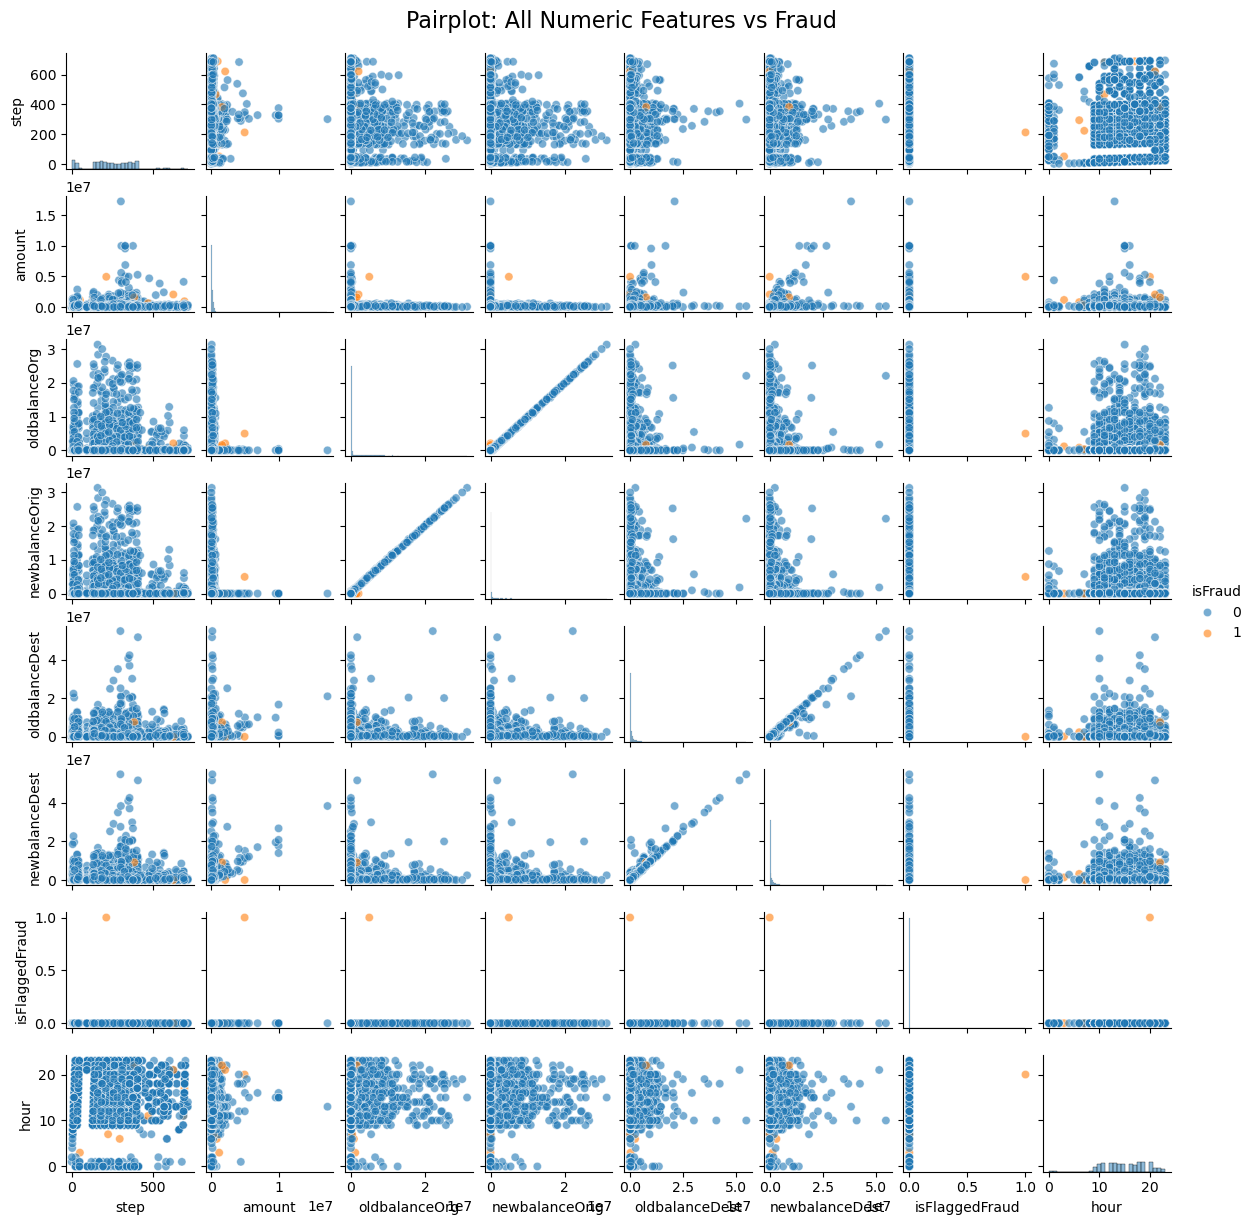

In [22]:
# Auto-select ALL numeric columns + isFraud
sample_df = df.sample(n=5000, random_state=42)

# Get all numeric columns (automatically)
numeric_cols = sample_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'isFraud' not in numeric_cols:
    numeric_cols.append('isFraud')  # Ensure target included

print(f"Using {len(numeric_cols)} numeric columns: {numeric_cols}")

# Create pairplot with ALL numeric features
sns.pairplot(sample_df[numeric_cols], 
             hue='isFraud', 
             diag_kind='hist', 
             plot_kws={'alpha': 0.6},
             height=1.5)
plt.suptitle('Pairplot: All Numeric Features vs Fraud', y=1.02, size=16)
plt.show()

There are several linear relationships between the features:
* `oldbalanceOrg` vs. `newbalanceOrig`
* `oldbalanceDest` vs. `newbalanceDest`

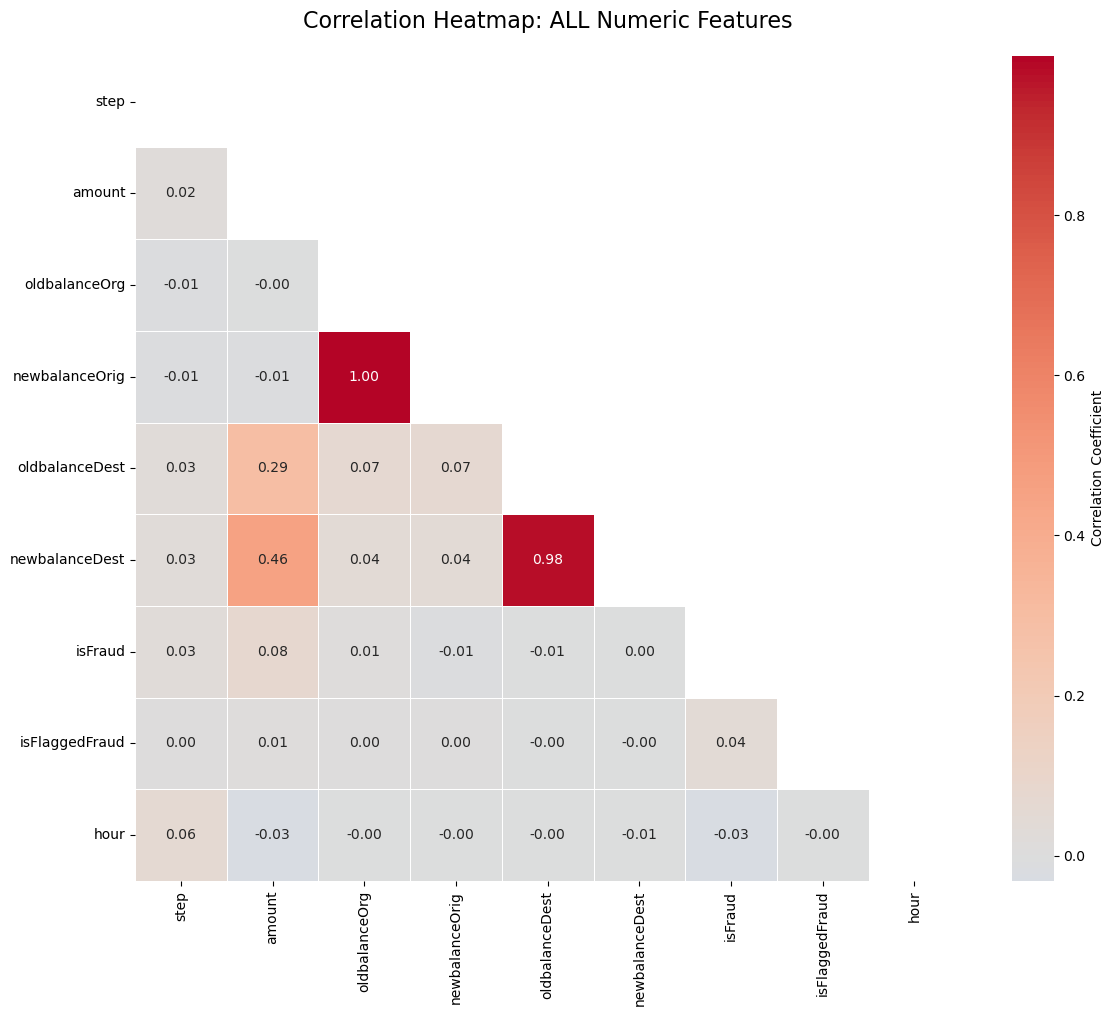

In [23]:
# Automatically select ALL numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()

# Create mask for upper triangle (cleaner view)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            mask=mask,              # Hide upper triangle
            annot=True,             # Show correlation values
            cmap='coolwarm',        # Red=+, Blue=-
            center=0,               # White=0 correlation
            fmt='.2f',              # 2 decimal places
            square=True,
            cbar_kws={'label': 'Correlation Coefficient'},
            linewidths=0.5)         # Thin lines between cells
plt.title('Correlation Heatmap: ALL Numeric Features', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

Correlation heatmap shows that same relationships between the highly correlated features. To combat multicollinearity, we can drop these features:
* `oldbalanceOrg`
* `newbalanceOrig`
* `oldbalanceDest`
* `newbalanceDest`

The information about the `amount`.

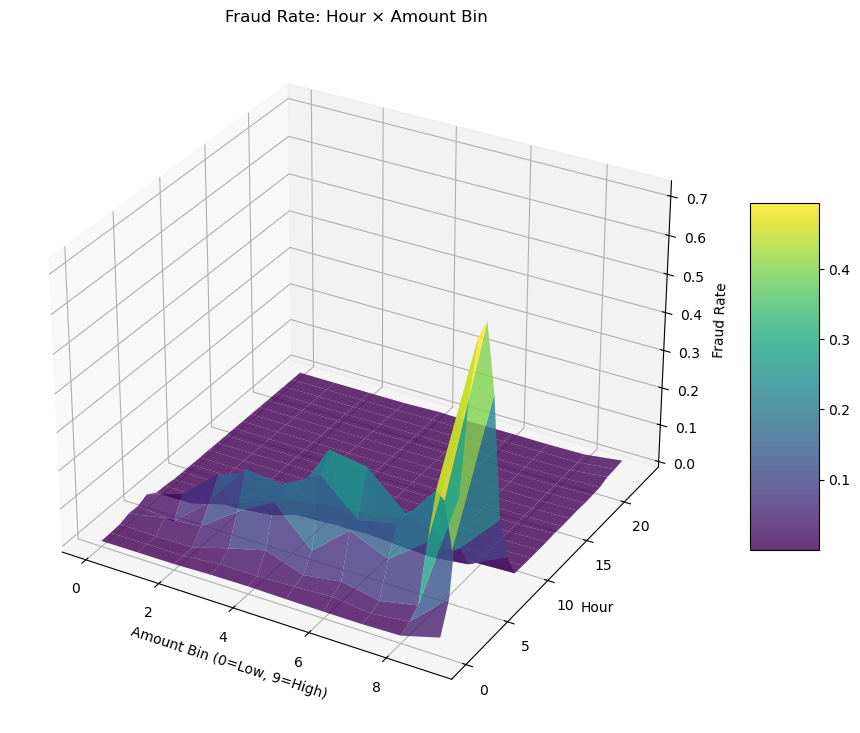

In [39]:
from mpl_toolkits.mplot3d import Axes3D

# Create numeric bins (not intervals)
df['amount_bin'] = pd.qcut(df['amount'], q=10, labels=False)  # ✅ Numeric labels (0-9)


# Group and pivot
grouped = df.groupby(['hour', 'amount_bin'])['isFraud'].mean().reset_index()
pivot_z = grouped.pivot(index='hour', columns='amount_bin', values='isFraud').fillna(0)


# Now meshgrid works
X, Y = np.meshgrid(pivot_z.columns, pivot_z.index)


# 3D Plot
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, pivot_z.values, cmap='viridis', alpha=0.8)


ax.set_xlabel('Amount Bin (0=Low, 9=High)')
ax.set_ylabel('Hour')
ax.set_zlabel('Fraud Rate')
ax.set_title('Fraud Rate: Hour × Amount Bin')


plt.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

Looks like fraud happens at the highest rate in the early mornings in large amounts.

In [42]:
df['diff_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['diff_dest'] = df['newbalanceDest'] - df['oldbalanceDest']
df['amt_equals_orig_balance'] = (df['amount'] == df['oldbalanceOrg']).astype(int)
df['orig_balance_zero_after'] = (df['newbalanceOrig'] == 0).astype(int)
df['dest_balance_unchanged'] = (df['oldbalanceDest'] == df['newbalanceDest']).astype(int)

balance_summary = df.groupby('isFraud')[[
    'amount', 'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest', 'diff_orig', 'diff_dest',
    'amt_equals_orig_balance', 'orig_balance_zero_after', 'dest_balance_unchanged'
]].mean()

print(balance_summary)

               amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
isFraud                                                                
0        1.781970e+05   8.328287e+05   855970.228109    1.101421e+06   
1        1.467967e+06   1.649668e+06   192392.631836    5.442496e+05   

         newbalanceDest     diff_orig      diff_dest  amt_equals_orig_balance  \
isFraud                                                                         
0          1.224926e+06 -2.314152e+04  123504.809994                 0.000000   
1          1.279708e+06  1.457275e+06  735457.998071                 0.978205   

         orig_balance_zero_after  dest_balance_unchanged  
isFraud                                                   
0                       0.566774                0.364032  
1                       0.980519                0.497504  


Fraudulent transactions stand out not just because they are larger on average, but because they produce distinctive balance patterns. In particular, fraud is strongly associated with the transaction amount matching the sender’s balance, the sender balance dropping to zero, and the destination balance often remaining unchanged.
